In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

In [ ]:
df=pd.read_excel('/content/drive/MyDrive/TimeSeriesForecasting/US_Unemployment_rate_cleaned.xlsx')

In [ ]:
df.head()

,Date,Value
0,2000-01-01,4.0
1,2000-02-01,4.1
2,2000-03-01,4.0
3,2000-04-01,3.8
4,2000-05-01,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    307 non-null    datetime64[ns]
 1   Value   307 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.9 KB


In [ ]:
df.set_index('Date',inplace=True)

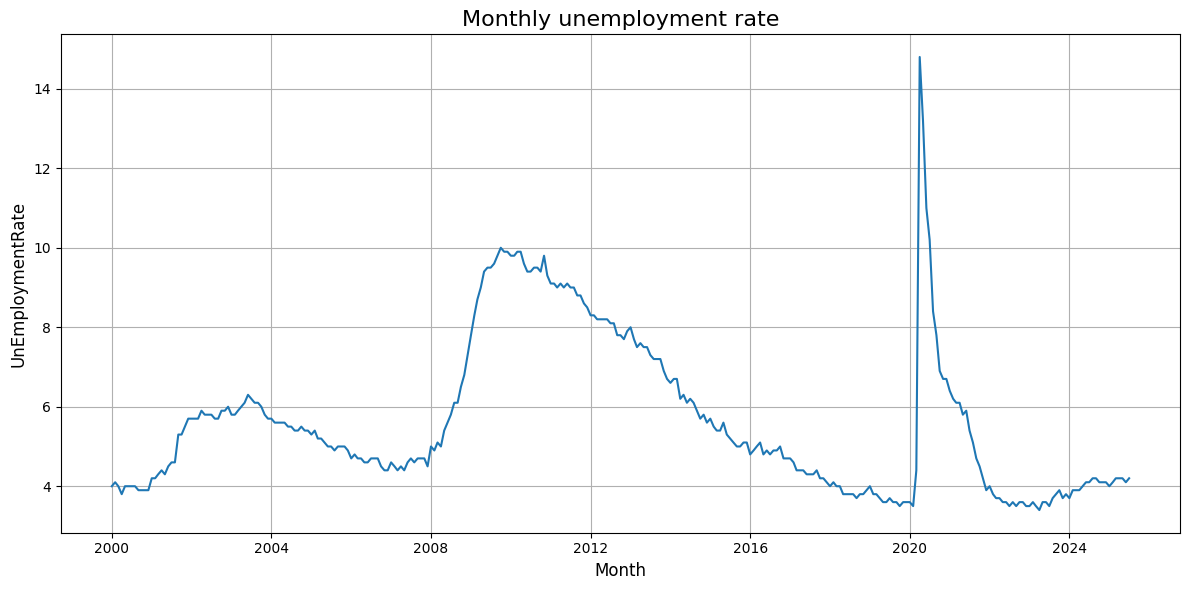

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Value'])
plt.title('Monthly unemployment rate', fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel('UnEmploymentRate', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

outliers_iqr = df[(df['Value'] < lower_bound) | (df['Value'] > upper_bound)]

In [ ]:
outliers_iqr

,Value
Date,
2020-04-01,14.8
2020-05-01,13.2
2020-06-01,11.0


In [ ]:
# Calculate the median of the non-outlier values
median_value = df[~((df['Value'] < lower_bound) | (df['Value'] > upper_bound))]['Value'].median()

# Impute outliers with the median
df['Value_imputed_iqr'] = df['Value'].copy()
df.loc[outliers_iqr.index, 'Value_imputed_iqr'] = median_value


In [ ]:
df["2020-01-01":"2020-12-01"]

,Value,Value_imputed_iqr
Date,,
2020-01-01,3.6,3.6
2020-02-01,3.5,3.5
2020-03-01,4.4,4.4
2020-04-01,14.8,5.0
2020-05-01,13.2,5.0
2020-06-01,11.0,5.0
2020-07-01,10.2,10.2
2020-08-01,8.4,8.4
2020-09-01,7.8,7.8


In [ ]:
df_no_2020=df[df.index.year!=2020]

In [ ]:
df_no_2020.index.year.unique()

Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024,
       2025],
      dtype='int32', name='Date')

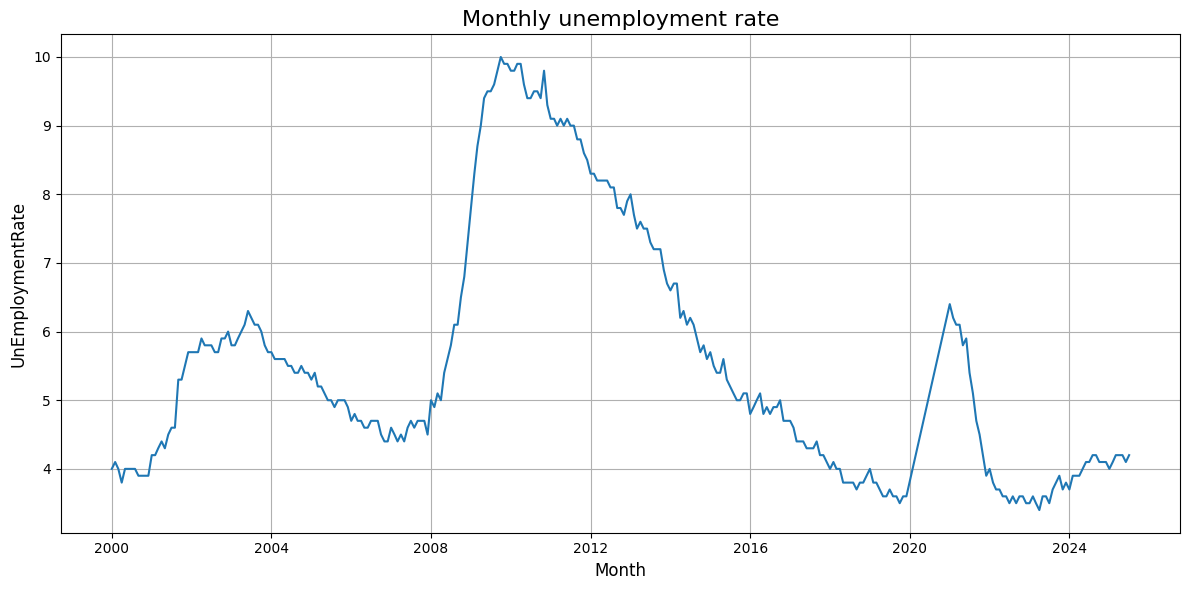

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_no_2020.index, df_no_2020['Value'])
plt.title('Monthly unemployment rate', fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel('UnEmploymentRate', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
train = df_no_2020[df_no_2020.index < "2024-01-01"]
test = df_no_2020[df_no_2020.index >= "2024-01-01"]

In [ ]:
# 3️⃣ Holt-Winters Model (Additive Trend & Seasonality)
model = ExponentialSmoothing(train['Value'], trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
forecast = fit.forecast(len(test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
mae = mean_absolute_error(test['Value'], forecast)

In [ ]:
mae

0.13443885265980823